# Low-Stress Network Fragmentation Score (`connectivity_lts`)

Existing bike-stress models score each street segment using only that segment's own attributes. This notebook adds one question for every segment
that looks **Low-stress**: is it part of a large, connected Low-stress network, or is it an isolated piece?

**Input:** the RideScore DC base-data snapshot dated 2026-09-29 (OpenStreetMap segments joined to DDOT attributes). No crash data, no existing pipeline scores.
**Output:** `results.parquet` (one row per snapshot segment) with `connectivity_lts` = `High`, `Medium`, `Low-Isolated` or `Low-Connected`. See `README.md` for assumptions and known gaps.

**Sections**
1. Environment and data load
2. Merge DDOT and OSM attributes
3. Stress classification
4. One-way streets: finding, fix, and the directed graph
5. Low-stress network: components, sizes, and the final classification
6. Map
7. Export

## 1. Environment and data load

Load the snapshot (Parquet) and confirm that the GeoJSON copy holds the same data. This notebook lives at `notebooks/low-stress-fragmentation/`,
so the data folder (`ridescore-data`, a sibling of the repo) is three levels up.

In [1]:
from collections import Counter, defaultdict
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import shapely

SNAPSHOT_DATE = "2026-09-29"
DATA_DIR = Path("../../../ridescore-data")
PARQUET_PATH = DATA_DIR / f"ridescore_dc_basemap_{SNAPSHOT_DATE}.parquet"
GEOJSON_PATH = DATA_DIR / f"ridescore_dc_basemap_{SNAPSHOT_DATE}.geojson"
ID_COLS = ["osm_u", "osm_v", "osm_key"]   # a segment's identity (valid within this snapshot only)

# Fail loudly if the data folder is wrong, rather than silently loading something else
for path in (PARQUET_PATH, GEOJSON_PATH):
    assert path.exists(), f"Snapshot file not found: {path.resolve()}"

print("geopandas", gpd.__version__, "| networkx", nx.__version__, "| pandas", pd.__version__)

geopandas 1.1.4 | networkx 3.7 | pandas 3.0.5


In [2]:
# Load the Parquet snapshot (main table, with geometry)
segments = gpd.read_parquet(PARQUET_PATH)
N_SNAPSHOT_SEGMENTS = len(segments)
print(f"{N_SNAPSHOT_SEGMENTS:,} segments x {segments.shape[1]} columns | CRS EPSG:{segments.crs.to_epsg()}")

# Cross-check against the GeoJSON copy: same shape and the same segment IDs
geojson_copy = gpd.read_file(GEOJSON_PATH)
same_ids = set(map(tuple, segments[ID_COLS].to_numpy())) == set(map(tuple, geojson_copy[ID_COLS].to_numpy()))
assert segments.shape == geojson_copy.shape and same_ids, "Parquet and GeoJSON differ"
del geojson_copy

# Segment IDs must be unique
assert not segments.duplicated(ID_COLS).any(), "duplicate segment IDs"
print("Parquet and GeoJSON agree; segment IDs are unique")

28,978 segments x 135 columns | CRS EPSG:4326
Parquet and GeoJSON agree; segment IDs are unique


## 2. Merge DDOT and OSM attributes

Build three clean columns: `speed_mph`, `lanes_total` and `has_bike_facility`.

- **Speed and lanes:** DDOT first, OSM as the fallback when DDOT is empty. OSM's text values (`"25 mph"`, `"2"`) are converted to numbers *before* merging.
  A DDOT speed of 0 mph is not a real limit, so it is treated as missing. A lane count of 0 is kept (DDOT uses it for paths with no car lanes).
- **Bike facility:** present if **any** source indicates one: DDOT (any `dc_BIKELANE_*` column is set), OSM (a `cycleway*` value of `lane`, `track`, `buffered_lane`
  or `opposite_lane`), or the segment is itself an off-street bike path (`cycleway`, `path`, `footway`). Anything else, including no tag at all, counts as **no facility**.

In [3]:
# Normalize OSM text to numbers first: "25 mph" -> 25.0 and "2" -> 2.0
osm_speed = pd.to_numeric(segments["osm_maxspeed"].str.replace(" mph", "", regex=False), errors="coerce")
osm_lanes = pd.to_numeric(segments["osm_lanes"], errors="coerce")

# DDOT values are already numeric; a 0 mph limit is not real, so treat it as missing
dc_speed = segments["dc_SPEEDLIMITS_OB"].where(segments["dc_SPEEDLIMITS_OB"] > 0)
dc_lanes = segments["dc_TOTALTRAVELLANES"]

# Merge: use DDOT, and fill any DDOT gaps from OSM
segments["speed_mph"] = dc_speed.combine_first(osm_speed)
segments["lanes_total"] = dc_lanes.combine_first(osm_lanes)

In [4]:
# Bike facility columns that indicate a facility
OSM_BIKE_COLS = ["osm_cycleway", "osm_cycleway_left", "osm_cycleway_right", "osm_cycleway_both"]
DC_BIKE_COLS = [c for c in segments.columns if c.startswith("dc_BIKELANE_")]
OSM_PRESENT_VALUES = {"lane", "track", "buffered_lane", "opposite_lane"}   # "no", "shared_lane", "separate" etc. do not count
OFFSTREET_PATH_TYPES = {"cycleway", "path", "footway"}                      # the segment is itself a bike path

osm_facility = segments[OSM_BIKE_COLS].isin(OSM_PRESENT_VALUES).any(axis=1)
dc_facility = segments[DC_BIKE_COLS].notna().any(axis=1)
is_offstreet_path = segments["osm_highway"].isin(OFFSTREET_PATH_TYPES)

# Present if any source says so; untagged everywhere means no facility
segments["has_bike_facility"] = osm_facility | dc_facility | is_offstreet_path

# What the merge produced
print(f"speed_mph missing:         {segments['speed_mph'].isna().sum():>6,}  ({segments['speed_mph'].isna().mean():.1%})")
print(f"lanes_total missing:       {segments['lanes_total'].isna().sum():>6,}  ({segments['lanes_total'].isna().mean():.1%})")
print(f"has_bike_facility = True:  {segments['has_bike_facility'].sum():>6,}  ({segments['has_bike_facility'].mean():.1%})")

speed_mph missing:          4,390  (15.1%)
lanes_total missing:        1,102  (3.8%)
has_bike_facility = True:   6,817  (23.5%)


## 3. Stress classification (`base_stress_class`)

Each segment is classified from its own attributes only. The first matching rule wins:

1. **Off-street path** (`cycleway`, `path`, `footway`) -> **Low**. There is no car traffic, so speed and lanes do not apply.
2. **High:** `speed_mph >= 35`, or `lanes_total >= 3` with no bike facility.
3. **Low:** `speed_mph <= 25` with a bike facility, **or** `speed_mph <= 20` with `lanes_total <= 2` and no facility.
4. **Unknown:** speed or lanes is missing and rules 1-3 could not decide.
5. **Medium:** everything else.

**Rationale and assumptions**
- Requiring a facility for every Low street would make almost every residential street Medium (only about 3% have a facility). Allowing every quiet street up to 25 mph made Low about 74% of the network and Medium almost empty.
  So a facility earns the 25 mph limit, and a street without one must be 20 mph or slower (the limit DDOT posts on most residential streets).
- A missing speed or lane count is never silently treated as Low or High: the segment is `Unknown`. `Unknown` becomes `Medium` only in the final column (Section 5), because that column allows 4 values.
- The thresholds are a first draft chosen by looking at the distribution, not validated against ground truth.

In [5]:
# Thresholds
LOW_MAX_SPEED_WITH_FACILITY = 25   # Low with a bike facility: speed at or below this
LOW_MAX_SPEED_NO_FACILITY = 20     # Low without a facility: speed at or below this (and few lanes)
LOW_MAX_LANES = 2                  # Low without a facility needs this many lanes or fewer
HIGH_MIN_SPEED_MPH = 35            # High at or above this speed
HIGH_MIN_LANES = 3                 # High with this many lanes and no facility


def classify_stress(df):
    # Return a Series of Low / Medium / High / Unknown for each segment
    speed, lanes, facility = df["speed_mph"], df["lanes_total"], df["has_bike_facility"]
    is_path = df["osm_highway"].isin(OFFSTREET_PATH_TYPES)

    # Each test is False (not an error) when its inputs are missing
    is_high = (speed >= HIGH_MIN_SPEED_MPH) | ((lanes >= HIGH_MIN_LANES) & ~facility)
    is_low = ((speed <= LOW_MAX_SPEED_WITH_FACILITY) & facility) | ((speed <= LOW_MAX_SPEED_NO_FACILITY) & (lanes <= LOW_MAX_LANES))
    has_gap = speed.isna() | lanes.isna()

    # First match wins: path, then High, then Low, then Unknown, else Medium
    result = pd.Series("Medium", index=df.index)
    result[has_gap] = "Unknown"
    result[is_low] = "Low"
    result[is_high] = "High"
    result[is_path] = "Low"
    return result


segments["base_stress_class"] = classify_stress(segments)

counts = segments["base_stress_class"].value_counts().reindex(["Low", "Medium", "High", "Unknown"])
pd.DataFrame({"segments": counts, "% of segments": (counts / len(segments) * 100).round(1)})

,segments,% of segments
base_stress_class,,
Low,18498,63.8
Medium,3180,11.0
High,4645,16.0
Unknown,2655,9.2


## 4. One-way streets: finding, fix, and the directed graph

To test whether a Low-stress street is reachable, we build a **directed** graph: bikes must follow one-way restrictions, except where a contraflow exemption applies.

**Finding.** The snapshot has one row per street. Its two directions were merged into a single row when the extract was built, so `osm_u` and `osm_v` are **in arbitrary order for one-way streets**.
Assuming `u -> v` is the legal direction would give about half of all one-way segments the wrong direction. The legal direction is carried by the **geometry**: the line is drawn in the direction of travel,
from its first point to its last point.

**Fix.** For each segment we work out which of its two nodes sits at the start of the geometry (by matching its end points with neighboring segments at `u` and at `v`).
A one-way segment becomes an edge from the start node to the end node. A two-way segment gets both directions, and a one-way segment with a bicycle contraflow exemption gets both too.

Sections 4a-4d: how segments are stored, a validation of the fix, contraflow exemptions, and the edge table. See the README for caveats.

### 4a. Which way does each geometry run?

First, each street should be a single row (no reverse twins). Then, for every segment, compare the first and last point of its geometry with the points where neighboring segments meet at `u` and `v`.
Result: `u_to_v` (geometry starts at `u`), `v_to_u`, `loop` (`u == v`), or `ambiguous` (no evidence either way). If `u -> v` were always the legal direction, every one-way row would be `u_to_v`.

In [6]:
# Reverse twins: a row (u, v, key) with another row (v, u, key). Self-loops (u == v) are their own twin, so exclude them.
ids = list(zip(segments["osm_u"], segments["osm_v"], segments["osm_key"]))
segment_ids = set(ids)
has_twin = pd.Series([(v, u, k) in segment_ids for u, v, k in ids], index=segments.index)
is_self_loop = segments["osm_u"] == segments["osm_v"]
print("segments with a reverse twin (excluding self-loops):", (has_twin & ~is_self_loop).sum(), "| self-loops:", is_self_loop.sum())

# Geometry end points, rounded to about 1 m so touching segments agree
first_xy = shapely.get_coordinates(shapely.get_point(segments.geometry.values, 0))
last_xy = shapely.get_coordinates(shapely.get_point(segments.geometry.values, -1))
first_pt = [tuple(p) for p in np.round(first_xy, 5)]
last_pt = [tuple(p) for p in np.round(last_xy, 5)]

# For each node, count how often each coordinate appears as a segment end among the segments touching it.
# The node's real location shows up in every touching segment, so it gets the highest count.
ends_at_node = defaultdict(Counter)
for u, v, a, b in zip(segments["osm_u"], segments["osm_v"], first_pt, last_pt):
    for node in (u, v):
        ends_at_node[node][a] += 1
        ends_at_node[node][b] += 1


def geometry_direction(u, v, a, b):
    # Does the geometry start at u (u_to_v) or at v (v_to_u)? Compare the evidence for each reading
    if u == v:
        return "loop"
    starts_at_u = ends_at_node[u][a] + ends_at_node[v][b]
    starts_at_v = ends_at_node[u][b] + ends_at_node[v][a]
    if starts_at_u == starts_at_v:
        return "ambiguous"
    return "u_to_v" if starts_at_u > starts_at_v else "v_to_u"


segments["geometry_runs"] = [geometry_direction(u, v, a, b)
                             for u, v, a, b in zip(segments["osm_u"], segments["osm_v"], first_pt, last_pt)]
pd.crosstab(segments["geometry_runs"], segments["osm_oneway"], margins=True)

segments with a reverse twin (excluding self-loops): 0 | self-loops: 82


osm_oneway,False,True,All
geometry_runs,,,
ambiguous,42,3,45
loop,49,33,82
u_to_v,16,5286,5302
v_to_u,18747,4802,23549
All,18854,10124,28978


### 4b. Validating the fix

Along a real one-way street, every segment should point the same way. We compare the compass heading of the **geometry** (first to last point) with the heading of `u -> v` over all long named one-way streets.
Then we check three streets against known facts:
- **T Street NE** between Lincoln Road and 2nd Street: one-way eastbound (DDOT notice NOI-21-67-TOA).
- **North Capitol Street NE and NW:** a divided road with right-hand traffic, so the NE carriageway runs north and the NW carriageway runs south.

In [7]:
# Compass heading (N/E/S/W) of the geometry, first point to last point
dx = (last_xy[:, 0] - first_xy[:, 0]) * np.cos(np.radians(38.9))   # shrink longitude to match latitude
dy = last_xy[:, 1] - first_xy[:, 1]
angle = np.degrees(np.arctan2(dx, dy)) % 360                         # 0 = north, 90 = east
segments["heading_geometry"] = np.array(["N", "E", "S", "W"])[((angle + 45) // 90).astype(int) % 4]

# Heading of u -> v: the same as the geometry, except flipped where the geometry runs v -> u
opposite = {"N": "S", "S": "N", "E": "W", "W": "E"}
segments["heading_u_to_v"] = [opposite[h] if r == "v_to_u" else h
                              for h, r in zip(segments["heading_geometry"], segments["geometry_runs"])]

one_way = segments["osm_oneway"]

# Long named one-way streets: how many are 90%+ consistent in one direction, by each reading?
streets = segments[one_way & segments["osm_name"].notna() & ~segments["osm_highway"].str.endswith("_link")
                   & segments["geometry_runs"].isin(["u_to_v", "v_to_u"])]
for label, column in [("geometry heading", "heading_geometry"), ("u -> v heading", "heading_u_to_v")]:
    share = streets.groupby("osm_name")[column].agg(
        segments="size", share=lambda s: s.value_counts(normalize=True).iloc[0])
    long_streets = share[share["segments"] >= 20]
    print(f"{label}: {(long_streets['share'] >= 0.9).sum()} of {len(long_streets)} streets (20+ segments) are 90%+ consistent")

# Three streets with a known one-way direction
known = {"T Street Northeast": "E", "North Capitol Street Northeast": "N", "North Capitol Street Northwest": "S"}
rows = []
for name, expected in known.items():
    headings = segments.loc[one_way & (segments["osm_name"] == name), "heading_geometry"]
    rows.append({"street": name, "expected heading": expected, "one-way segments": len(headings),
                 "matching expected": int((headings == expected).sum())})
pd.DataFrame(rows).set_index("street")

geometry heading: 30 of 111 streets (20+ segments) are 90%+ consistent
u -> v heading: 0 of 111 streets (20+ segments) are 90%+ consistent


,expected heading,one-way segments,matching expected
street,,,
T Street Northeast,E,8,7
North Capitol Street Northeast,N,79,79
North Capitol Street Northwest,S,84,82


### 4c. Contraflow exemptions

A one-way street normally lets bikes go only in its legal direction. The reverse direction is also allowed when any of these signals says bikes may ride against traffic:
- `osm_oneway_bicycle == "no"` (OSM: the one-way does not apply to bikes)
- `dc_BIKELANE_CONTRAFLOW` is set (DDOT: a contraflow bike lane)
- an OSM cycleway value of `opposite_lane`
- `osm_cycleway_left_oneway == "-1"` (a left-side lane running against the street)

An explicit `osm_oneway_bicycle == "yes"` (bikes are restricted too) overrides the other signals. One-way segments whose geometry direction is `ambiguous` are treated as two-way, since we cannot tell which way is legal.

In [8]:
# One True/False column per contraflow signal
signals = pd.DataFrame({
    "OSM oneway:bicycle = no": segments["osm_oneway_bicycle"] == "no",
    "DDOT contraflow lane": segments["dc_BIKELANE_CONTRAFLOW"].notna(),
    "OSM opposite_lane": segments[OSM_BIKE_COLS].isin(["opposite_lane"]).any(axis=1),
    "OSM left cycleway oneway = -1": segments["osm_cycleway_left_oneway"] == "-1",
})
bikes_restricted = segments["osm_oneway_bicycle"] == "yes"   # OSM says bikes must obey the one-way too

# A one-way segment lets bikes travel both ways only with an unrestricted contraflow signal
contraflow_exempt = one_way & signals.any(axis=1) & ~bikes_restricted
unknown_direction = one_way & (segments["geometry_runs"] == "ambiguous")
segments["allows_reverse"] = ~one_way | contraflow_exempt | unknown_direction

print(f"one-way segments: {one_way.sum():,} | with a contraflow exemption: {contraflow_exempt.sum():,}")
print(signals[one_way].sum().to_string())
print(f"segments with both directions: {segments['allows_reverse'].sum():,} | one direction only: {(~segments['allows_reverse']).sum():,}")

one-way segments: 10,124 | with a contraflow exemption: 381
OSM oneway:bicycle = no          180
DDOT contraflow lane             330
OSM opposite_lane                 79
OSM left cycleway oneway = -1     60
segments with both directions: 19,238 | one direction only: 9,740


### 4d. The directed edge table

One row per directed edge, keyed by the segment it came from. The main edge goes from the node where the geometry **starts** to the node where it **ends**.
A segment with both directions allowed gets a second, reversed edge. We keep this as a table (not yet a graph) so each edge keeps its segment's stress class.

In [9]:
# Which node does each segment's geometry start at? Usually u, but v for the "v_to_u" segments
runs_backwards = segments["geometry_runs"] == "v_to_u"
start_node = segments["osm_v"].where(runs_backwards, segments["osm_u"])
end_node = segments["osm_u"].where(runs_backwards, segments["osm_v"])

# Main edge for every segment: geometry start -> geometry end
edge_cols = ["osm_u", "osm_v", "osm_key", "base_stress_class"]
forward = segments[edge_cols].assign(src=start_node, dst=end_node, direction="forward")

# Reverse edge where bikes may travel both ways; a self-loop's reverse is the same edge, so skip it
reverse_mask = segments["allows_reverse"] & ~is_self_loop
reverse = segments.loc[reverse_mask, edge_cols].assign(
    src=end_node[reverse_mask], dst=start_node[reverse_mask], direction="reverse")

edges = pd.concat([forward, reverse], ignore_index=True)

# Every segment must appear once or twice, and the counts must add up
assert len(edges) == len(segments) + reverse_mask.sum()
assert edges.groupby(ID_COLS).size().isin([1, 2]).all()
print(f"{len(segments):,} segments -> {len(edges):,} directed edges ({len(reverse):,} reverse edges)")

28,978 segments -> 48,167 directed edges (19,189 reverse edges)


## 5. Low-stress network: components, sizes, and the final classification

Keep only the **Low** edges and find the **strongly connected components**: sets of nodes where you can get from any node to any other **and back again** while following one-way directions.

- A Low segment belongs to a component when both of its end nodes are in it.
- A one-way Low segment can have its two end nodes in *different* components (no way back through Low streets). We call it a **cross-edge**; it has no component and counts as isolated.
- `component_size_segments` / `component_size_m` give the size of the segment's component (a cross-edge is its own size: 1 segment and its own length). They are empty for non-Low segments, never 0.
- `is_isolated` is `True` for cross-edges and for components shorter than `ISOLATION_CUTOFF_M` (500 m). It is empty for non-Low segments.
- `connectivity_lts`: High and Medium pass through, Unknown becomes Medium, and Low splits into `Low-Isolated` or `Low-Connected`.
- `is_one_way_bridge` and `cross_edge_large_ends` describe cross-edges (see 5c).

In [10]:
is_low = segments["base_stress_class"] == "Low"

# Only Low edges go into the graph (Medium, High and Unknown segments never become edges).
# Collapsing parallel edges into one graph edge is safe here because every edge is already Low.
low_edges = edges[edges["base_stress_class"] == "Low"]
G_low = nx.from_pandas_edgelist(low_edges, "src", "dst", create_using=nx.DiGraph)

# Strongly connected components: a list of node sets, largest first; then a component number for every node
components = sorted(nx.strongly_connected_components(G_low), key=len, reverse=True)
node_component = {node: number for number, nodes in enumerate(components) for node in nodes}
print(f"Low graph: {G_low.number_of_nodes():,} nodes, {G_low.number_of_edges():,} directed edges, {len(components):,} strongly connected components")

Low graph: 16,678 nodes, 32,388 directed edges, 1,723 strongly connected components


In [11]:
# Component of each end node (only meaningful for Low segments)
scc_u = segments["osm_u"].map(node_component)
scc_v = segments["osm_v"].map(node_component)
assert scc_u[is_low].notna().all() and scc_v[is_low].notna().all(), "a Low segment's node is missing from the Low graph"

# Same component at both ends -> that component; different -> cross-edge
same_component = is_low & (scc_u == scc_v)
segments["scc_id"] = scc_u.where(same_component).astype("Int64")      # empty for non-Low segments and cross-edges
segments["is_cross_edge"] = is_low & (scc_u != scc_v)

print(f"Low segments: {is_low.sum():,} | in a component: {same_component.sum():,} | cross-edges: {segments['is_cross_edge'].sum():,}")

Low segments: 18,498 | in a component: 17,163 | cross-edges: 1,335


### 5a. Component sizes

Lengths are measured in EPSG:26985 (Maryland State Plane, meters). Sizes are summed over `segments` rows, and each row is one physical segment, so a two-way street is never counted twice
(summing the directed edge table would count it twice). The sizing is a small function with a test on hand-made examples.

In [12]:
# Length of every segment in meters
segments["length_m"] = segments.geometry.to_crs("EPSG:26985").length


def component_sizes(low):
    # For Low segments (columns scc_id, is_cross_edge, length_m): size of each one's component
    in_component = ~low["is_cross_edge"]
    per_component = low[in_component].groupby("scc_id")["length_m"]
    n_segments = low["scc_id"].map(per_component.size())
    n_meters = low["scc_id"].map(per_component.sum())
    # A cross-edge is its own component: one segment, its own length
    return n_segments.where(in_component, 1), n_meters.where(in_component, low["length_m"])


# Test on tiny examples: one 120 m segment must give 120 (not 240); two segments in a component share one total; a cross-edge is on its own
toy = pd.DataFrame({
    "scc_id": pd.array([0, 1, 1, pd.NA], dtype="Int64"),
    "is_cross_edge": [False, False, False, True],
    "length_m": [120.0, 100.0, 50.0, 80.0],
})
toy_segments, toy_meters = component_sizes(toy)
assert list(toy_meters) == [120.0, 150.0, 150.0, 80.0] and list(toy_segments) == [1, 2, 2, 1]

# Attach sizes to the Low segments (every other segment stays empty)
n_segments, n_meters = component_sizes(segments[is_low])
segments["component_size_segments"] = n_segments.astype("Int64")
segments["component_size_m"] = n_meters

# Check: every Low segment is counted exactly once (components' totals + cross-edges add up to the Low length)
low = segments[is_low]
cross = low["is_cross_edge"]
component_total = low[~cross].groupby("scc_id")["component_size_m"].first().sum()
assert abs((component_total + low.loc[cross, "length_m"].sum()) - low["length_m"].sum()) < 1e-6
assert segments.loc[~is_low, "component_size_m"].isna().all()
print(f"sized {segments['component_size_m'].notna().sum():,} Low segments | network length {segments['length_m'].sum() / 1000:,.0f} km")

sized 18,498 Low segments | network length 2,165 km


### 5b. Isolated flag and the final classification `connectivity_lts`

| `base_stress_class` | `connectivity_lts` |
|---|---|
| High | High |
| Medium | Medium |
| Unknown | Medium (the final column only allows 4 values) |
| Low, isolated | Low-Isolated |
| Low, not isolated | Low-Connected |

In [13]:
ISOLATION_CUTOFF_M = 500   # a Low component shorter than this counts as isolated

# Isolated: a cross-edge, or a component shorter than the cutoff. Empty for non-Low segments.
isolated = segments["is_cross_edge"] | (segments["component_size_m"] < ISOLATION_CUTOFF_M)
segments["is_isolated"] = isolated.where(is_low).astype("boolean")

# Final classification: start from the base class (Unknown -> Medium), then split Low
connectivity = segments["base_stress_class"].replace({"Unknown": "Medium"})
connectivity[is_low & (segments["is_isolated"] == True)] = "Low-Isolated"
connectivity[is_low & (segments["is_isolated"] == False)] = "Low-Connected"
segments["connectivity_lts"] = connectivity

# Checks: only 4 values, High and Medium are untouched, and exactly the Low segments are split
assert set(segments["connectivity_lts"].unique()) == {"High", "Medium", "Low-Isolated", "Low-Connected"}
assert (segments.loc[segments["base_stress_class"] == "High", "connectivity_lts"] == "High").all()
assert (segments.loc[segments["base_stress_class"] == "Medium", "connectivity_lts"] == "Medium").all()
assert (segments["connectivity_lts"].isin(["Low-Isolated", "Low-Connected"]) == is_low).all()

print("Unknown segments mapped to Medium:", (segments["base_stress_class"] == "Unknown").sum())
pd.crosstab(segments["base_stress_class"], segments["connectivity_lts"], margins=True)

Unknown segments mapped to Medium: 2655


connectivity_lts,High,Low-Connected,Low-Isolated,Medium,All
base_stress_class,,,,,
High,4645,0,0,0,4645
Low,0,16449,2049,0,18498
Medium,0,0,0,3180,3180
Unknown,0,0,0,2655,2655
All,4645,16449,2049,5835,28978


### 5c. Cross-edge columns

For each cross-edge, `cross_edge_large_ends` counts how many of its two end nodes belong to a component at least `ISOLATION_CUTOFF_M` long (0, 1 or 2); it is empty for every other segment.
`is_one_way_bridge` is `True` when that count is 2 and `False` otherwise. These columns do not change `connectivity_lts`; a cross-edge is `Low-Isolated` either way.
They only look at the two direct end components.

In [14]:
# Total length of each component (only Low segments that belong to one)
component_length = segments[same_component].groupby("scc_id")["length_m"].sum()

# Length of the component at each end of every segment (a node with no component segments has length 0)
length_at_u = segments["osm_u"].map(node_component).map(component_length).fillna(0)
length_at_v = segments["osm_v"].map(node_component).map(component_length).fillna(0)

# How many of a cross-edge's two ends sit in a large component? (0, 1 or 2; empty for non-cross-edges)
large_ends = (length_at_u >= ISOLATION_CUTOFF_M).astype(int) + (length_at_v >= ISOLATION_CUTOFF_M).astype(int)
segments["cross_edge_large_ends"] = large_ends.where(segments["is_cross_edge"]).astype("Int64")
segments["is_one_way_bridge"] = segments["cross_edge_large_ends"].eq(2).fillna(False).astype(bool)

cross_edges = segments[segments["is_cross_edge"]]
counts = cross_edges["cross_edge_large_ends"].value_counts().sort_index()
pd.DataFrame({"cross-edges": counts, "% of cross-edges": (counts / len(cross_edges) * 100).round(1)}).rename_axis("large end components")

,cross-edges,% of cross-edges
large end components,,
0,804,60.2
1,526,39.4
2,5,0.4


### 5d. Summary

Segments and length in each final class, and the share of single-segment Low-stress streets that are isolated.

In [15]:
# Segments and length (km) in each final class
summary = segments.groupby("connectivity_lts").agg(segments=("osm_u", "size"), km=("length_m", lambda s: s.sum() / 1000)).round(0)
summary = summary.loc[["High", "Medium", "Low-Isolated", "Low-Connected"]]
summary["% of segments"] = (summary["segments"] / len(segments) * 100).round(1)
display(summary)

# Share of Low-stress segments that are isolated
n_low = is_low.sum()
n_isolated = (segments["connectivity_lts"] == "Low-Isolated").sum()
print(f"Low-stress by single-segment rules: {n_low:,} segments")
print(f"  Low-Connected: {n_low - n_isolated:,} ({(n_low - n_isolated) / n_low:.1%})")
print(f"  Low-Isolated:  {n_isolated:,} ({n_isolated / n_low:.1%})")

,segments,km,% of segments
connectivity_lts,,,
High,4645,339.0,16.0
Medium,5835,445.0,20.1
Low-Isolated,2049,144.0,7.1
Low-Connected,16449,1237.0,56.8


Low-stress by single-segment rules: 18,498 segments
  Low-Connected: 16,449 (88.9%)
  Low-Isolated:  2,049 (11.1%)


## 6. Map

All four `connectivity_lts` classes. `Low-Isolated` is drawn last (on top) and thicker so it stands out.

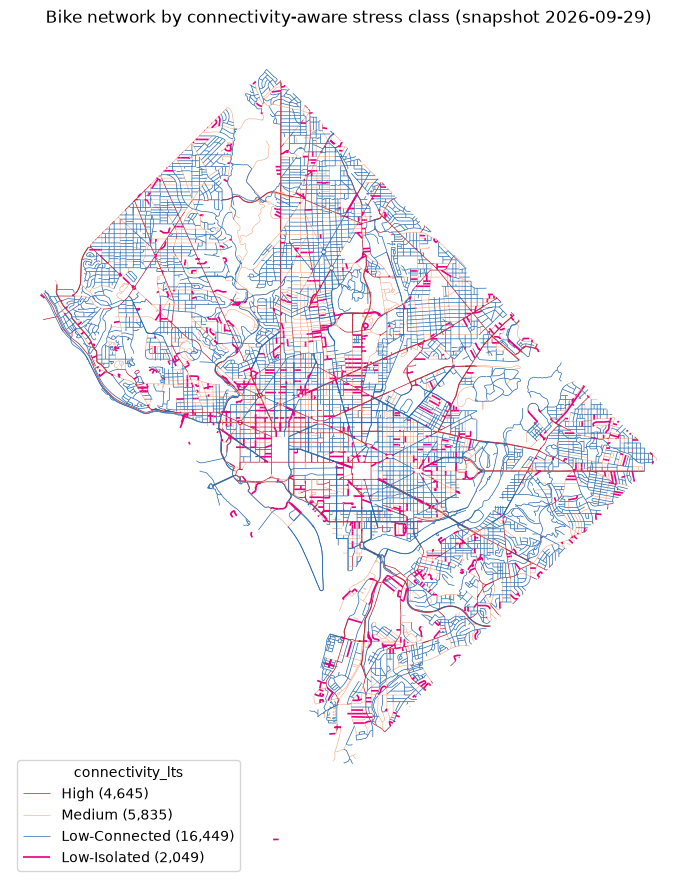

In [16]:
colors = {"High": "#b2182b", "Medium": "#f4a582", "Low-Connected": "#2166ac", "Low-Isolated": "#e6007e"}
widths = {"High": 0.5, "Medium": 0.4, "Low-Connected": 0.5, "Low-Isolated": 1.2}

fig, ax = plt.subplots(figsize=(11, 11))
for label in ["High", "Medium", "Low-Connected", "Low-Isolated"]:
    subset = segments[segments["connectivity_lts"] == label]
    subset.plot(ax=ax, color=colors[label], linewidth=widths[label], label=f"{label} ({len(subset):,})")
ax.legend(loc="lower left", title="connectivity_lts")
ax.set_axis_off()
ax.set_title("Bike network by connectivity-aware stress class (snapshot 2026-09-29)")
fig.savefig("connectivity_lts_map.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Export

One row per snapshot segment, with the required ID columns, the snapshot date, the model column and the supporting columns. Non-Low segments have empty
component, `is_isolated` and `cross_edge_large_ends` values (never 0). Geometry is not included: rows join back to the snapshot by `osm_u`, `osm_v`, `osm_key` and `snapshot_date`.

In [17]:
segments["snapshot_date"] = SNAPSHOT_DATE
RESULT_COLUMNS = ["osm_u", "osm_v", "osm_key", "snapshot_date", "connectivity_lts", "base_stress_class",
                  "component_size_segments", "component_size_m", "is_isolated", "is_one_way_bridge", "cross_edge_large_ends"]
results = pd.DataFrame(segments[RESULT_COLUMNS])

# One row per snapshot segment, nothing dropped or duplicated
assert len(results) == N_SNAPSHOT_SEGMENTS
assert not results.duplicated(ID_COLS).any()

results.to_parquet("results.parquet", index=False)

# Read the file back and confirm it is what we wrote
saved = pd.read_parquet("results.parquet")
assert saved.shape == results.shape and list(saved.columns) == RESULT_COLUMNS
print(f"wrote results.parquet: {len(saved):,} rows x {saved.shape[1]} columns")
saved.dtypes.to_frame("dtype")

wrote results.parquet: 28,978 rows x 11 columns


,dtype
osm_u,int64
osm_v,int64
osm_key,int32
snapshot_date,str
connectivity_lts,str
base_stress_class,str
component_size_segments,Int64
component_size_m,float64
is_isolated,boolean
is_one_way_bridge,bool
